In [321]:
import numpy as np
from pathlib import Path


def parse_textfile(filename):
    """

    :param filename: A string which contains the file to parse
    :return: result: A dictionary which contains the headers and data from a .txt file
    """

    header = {}
    data_rows = []
    current_key = None

    with Path(filename).open("r", encoding="utf-8") as f:
        for line in f:
            stripped = line.strip()
            if not stripped:
                continue

            if stripped.startswith("#"):
                current_key = stripped[1:].strip()
                if current_key != "DATA":
                    header[current_key] = []
            elif current_key == "DATA":
                data_rows.append(stripped)
            elif current_key is not None:
                header[current_key].append(stripped)

    # Join multi-line values (e.g. COMMENT) into single strings
    result = {key: " ".join(values) for key, values in header.items()}

    # First data row is the column header (WAVELENGTH,FLUX)
    if data_rows:
        columns = [c.strip() for c in data_rows[0].split(",")]
        data = {col: [] for col in columns}
        for row in data_rows[1:]:
            for col, value in zip(columns, row.split(",")):
                data[col].append(float(value))
        result["DATA"] = data # Separate the data from the header information

    return result

def get_spectrum(filename):
    """
    :param filename: A string which contains the file to parse
    :return: wavelength, flux : Lists of floats which contains wavelength and flux data, from the spectrum
    """

    spectrum = parse_textfile("spectrum.txt")
    wavelength = spectrum["DATA"]["WAVELENGTH"]
    flux = spectrum["DATA"]["FLUX"]
    return wavelength, flux

wavelength, flux = get_spectrum("spectrum.txt")

In [322]:
print(f"Wavelength list length: {len(wavelength)}")
print(len(flux))
print(type(flux[0]))
# established that these are floats


Wavelength list length: 2878
2878
<class 'float'>


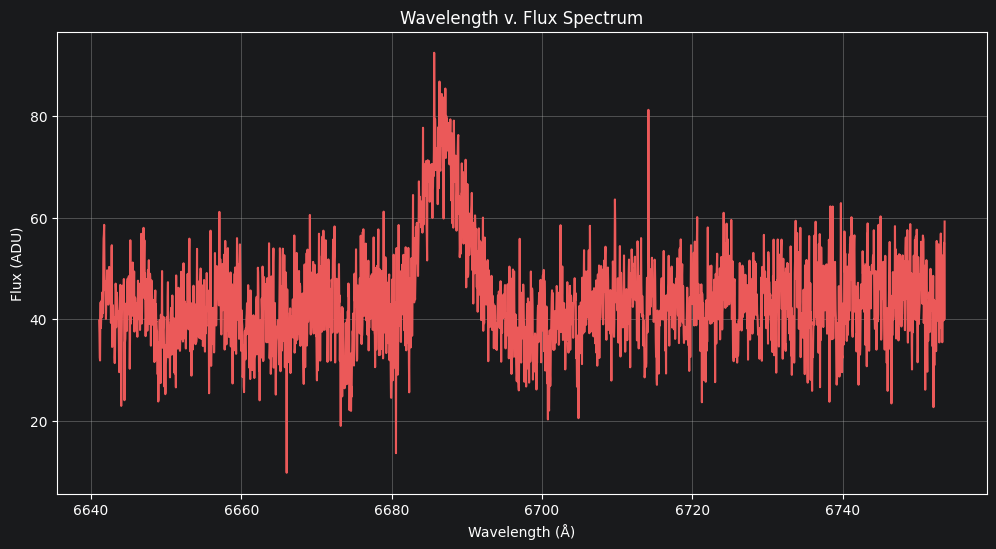

In [323]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wavelength, flux, c='#EB5959')
ax.set_title("Wavelength v. Flux Spectrum")
ax.set_xlabel(f"Wavelength (Å)")
ax.set_ylabel(f"Flux (ADU)")
ax.grid(True)

In [324]:
# Need to smooth (perhaps using a median filter)
# Fitting a low order polynomial works to estimate the continuum
# Finding important information about the max/ min and ranges before finding

max_wv = np.max(wavelength)
min_wv = np.min(wavelength)
print(f"Max wavelength: {max_wv}, Min wavelength: {min_wv}")
avg_wv = np.average(wavelength)
print(f"Average wavelength: {avg_wv}")

max_flux = np.max(flux)
min_flux = np.min(flux)
print(f"Max flux: {max_flux}, Min flux: {min_flux}")
avg_flux = np.average(flux)
print(f"Average flux: {avg_flux}")

std_wavelength = np.std(wavelength)
std_flux = np.std(flux)
print(f"Standard deviation: {std_wavelength}, Standard deviation: {std_flux}")

Max wavelength: 6753.5678, Min wavelength: 6641.0923
Average wavelength: 6697.330046594858
Max flux: 92.5325, Min flux: 9.7528
Average flux: 43.81535559416261
Standard deviation: 32.480137713424384, Standard deviation: 9.407320054301705


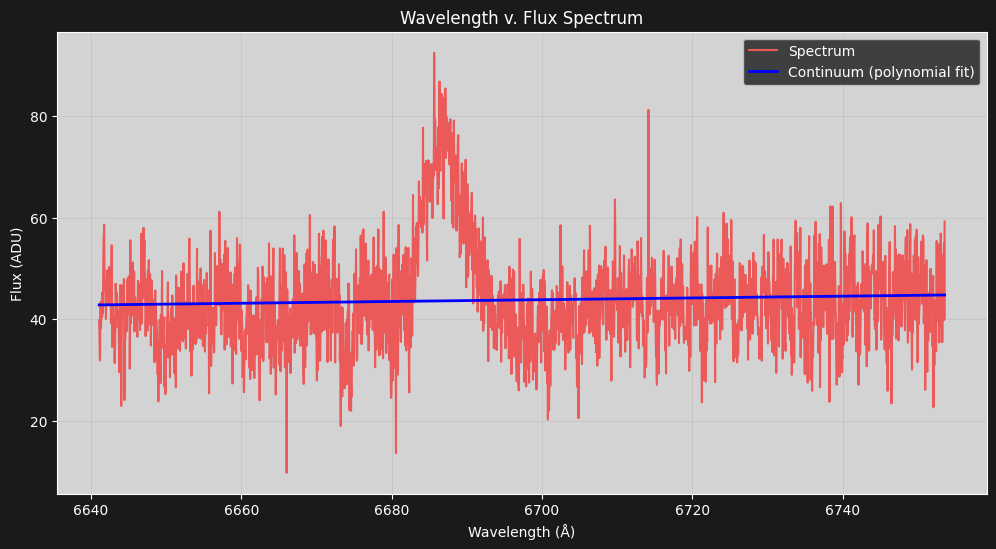

Wave Range: 6641.1 to 6753.6
Slope: 0.01739173669402248
Intercept : -72.66284512918054


In [325]:
def find_continuum(wave, flux):
    """

    :param wave: Wavelength data
    :param flux: Flux data :
    :return: The baseline continuum fit using polyfit and the slope
    """
    coeffs = np.polyfit(wave, flux, deg=1) # Evaluate the coefficients of the polynomial to degree = 1, y = mx+c
    slope = coeffs[0]
    intercept = coeffs[1]

    # Evaluates the polynomial at the values of the wave function
    continuum = np.polyval(coeffs, wave)

    return continuum, slope, intercept

continuum, slope, intercept = find_continuum(wavelength, flux)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wavelength, flux, c='#EB5959', label="Spectrum")
ax.plot(wavelength, continuum, c='blue', lw=2, label="Continuum (polynomial fit)")
ax.set_title("Wavelength v. Flux Spectrum")
ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Flux (ADU)")
ax.set_facecolor('lightgrey')
ax.grid(True)
ax.legend()
plt.show()
print(f"Wave Range: {min(wavelength):.1f} to {max(wavelength):.1f}")
print(f"Slope: {slope}")
print(f"Intercept : {intercept}")


wave range: 6641.1 to 6753.6
Peak Wave: 6685.6603
Slope: 0.0364513698101411
Intercept : -202.21357345033493


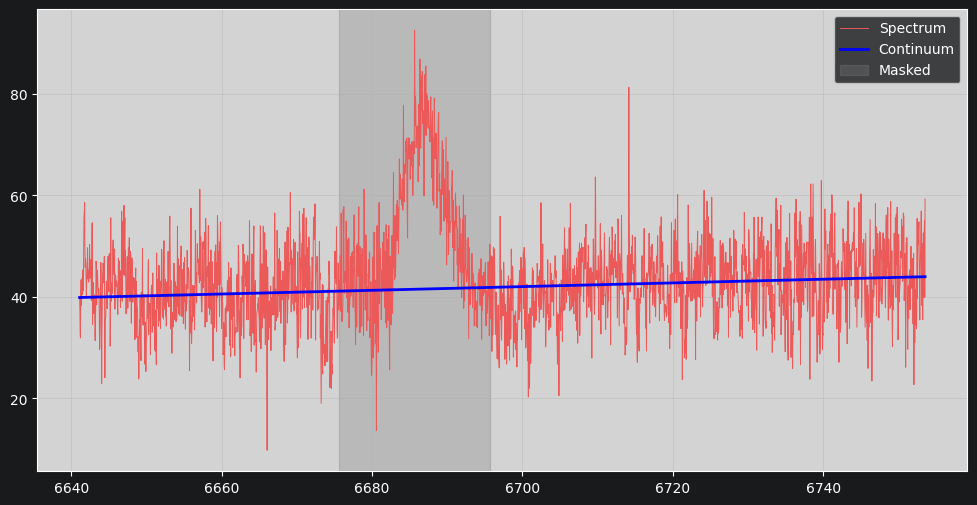

In [326]:
def find_continuum_masked(wave, flux, wv_width=10):
    wave = np.asarray(wave, dtype=float)
    flux = np.asarray(flux, dtype=float)

    peak_wave = wave[np.argmax(flux)]

    # Creates a mask to remove the emission peak from being in polyfit
    mask = np.abs(wave - peak_wave) > wv_width

    coeffs = np.polyfit(wave[mask], flux[mask], deg=1)
    continuum_masked = np.polyval(coeffs, wave)
    slope = coeffs[0]
    intercept = coeffs[1]
    return continuum_masked, slope, mask, peak_wave, intercept

continuum_masked, slope, mask, peak_wave, intercept = find_continuum_masked(wavelength, flux)
print(f"wave range: {min(wavelength):.1f} to {max(wavelength):.1f}")
print(f"Peak Wave: {peak_wave}")
print(f"Slope: {slope}")
print(f"Intercept : {intercept}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wavelength, flux, c='#EB5959', lw=0.7, label="Spectrum")
ax.plot(wavelength, continuum_masked, c='b', lw=2, label="Continuum")
ax.axvspan(peak_wave - 10, peak_wave + 10, color='gray', alpha=0.3, label="Masked")
ax.set_facecolor('lightgrey')
ax.legend()
ax.grid(True)
plt.show()

Part 3: Fitting a Gaussian to the Emission Line Peak

In [327]:
import numpy as np
from scipy.optimize import curve_fit

def gauss(x, A, mu, sigma):
    """Gaussian centred on zero baseline. Add c0 later"""
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def new_continuum(wave, flux): # Same Function as before
    """
    :param wave: Wavelength data
    :param flux:
    :return:
    """
    coeffs = np.polyfit(wave, flux, deg=1)
    slope = coeffs[0]
    c0 = np.polyval(coeffs, wave)
    return c0, slope

def fit_gaussian(wave, flux, region_width=10.0, sigma_guess=0.5):
    wave = np.asarray(wave, dtype=float)
    flux = np.asarray(flux, dtype=float)

    # Baseline (uses the continuum which does not remove the emission line peak)
    c0, slope = new_continuum(wave, flux)
    peak_wave = wave[np.argmax(flux)]

    # The flux line = the flux array - the continuum
    line_base = flux - c0

    # Fit only the region around the peak
    peak_region = np.abs(wave - peak_wave) < region_width
    wv_base, flux_base = wave[peak_region], line_base[peak_region]

    # Starting guesses: [A, mu, sigma]
    p0 = [flux_base.max(), peak_wave, sigma_guess]

    gopt, gcov = curve_fit(gauss, wv_base, flux_base, p0=p0)
    gerr = np.sqrt(np.diag(gcov))

    # Fitted line sitting on top of the baseline, at every wavelength
    line = c0 + gauss(wave, *gopt)
    fwhm = 2.355 * abs(gopt[2])

    return gopt, gerr, line, fwhm, c0, slope

centre = 6686.931 ± 0.065 Å, FWHM =  5.482744 ± 0.154 Å, amplitude = 32.43 ± 0.787 ADU
Slope: 0.01739173669402248


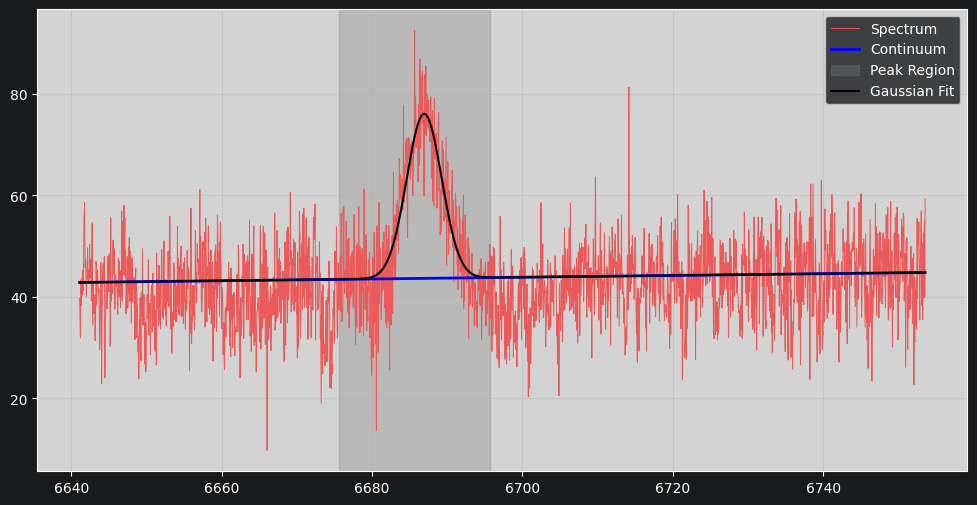

In [328]:
gopt, gerr, line, fwhm, c0, slope = fit_gaussian(wavelength, flux)
A, mu, sigma = gopt
A_err, mu_err, sigma_err = gerr
fwhm_err = 2.355*sigma_err

print(f"centre = {mu:.3f} ± {mu_err:.3f} Å, FWHM = {fwhm: .6f} ± {fwhm_err:.3f} Å, amplitude = {A:.2f} ± {A_err:.3f} ADU")
print(f"Slope: {slope}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wavelength, flux, c='#EB5959', lw=0.7, label="Spectrum")
ax.plot(wavelength, c0, c='b', lw=2, label="Continuum")
ax.axvspan(peak_wave - 10, peak_wave + 10, color='gray', alpha=0.3, label="Peak Region")

ax.set_facecolor('lightgrey')
plt.plot(wavelength, line, c='k', lw=1.5, label="Gaussian Fit")

plt.legend()
plt.grid(True)


plt.show()